<a href="https://colab.research.google.com/github/Bhavanam-Gireesh-Reddy/Incremental/blob/main/Copy_of_Incremental_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-small")

print("Path to dataset files:", path)

# Verify if the dataset was downloaded
if os.path.exists(path):
    print("Dataset downloaded successfully to:", path)
else:
    print("Dataset download failed or path does not exist.")

Using Colab cache for faster access to the 'fashion-product-images-small' dataset.
Path to dataset files: /kaggle/input/fashion-product-images-small
Dataset downloaded successfully to: /kaggle/input/fashion-product-images-small


In [3]:
import os

# List the contents of the downloaded directory
print(f"Contents of {path}:")
for root, dirs, files in os.walk(path):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

Streaming output truncated to the last 5000 lines.
/kaggle/input/fashion-product-images-small/images/38138.jpg
/kaggle/input/fashion-product-images-small/images/25383.jpg
/kaggle/input/fashion-product-images-small/images/45661.jpg
/kaggle/input/fashion-product-images-small/images/48569.jpg
/kaggle/input/fashion-product-images-small/images/12782.jpg
/kaggle/input/fashion-product-images-small/images/39170.jpg
/kaggle/input/fashion-product-images-small/images/55612.jpg
/kaggle/input/fashion-product-images-small/images/30616.jpg
/kaggle/input/fashion-product-images-small/images/6118.jpg
/kaggle/input/fashion-product-images-small/images/19177.jpg
/kaggle/input/fashion-product-images-small/images/43477.jpg
/kaggle/input/fashion-product-images-small/images/25346.jpg
/kaggle/input/fashion-product-images-small/images/6136.jpg
/kaggle/input/fashion-product-images-small/images/54674.jpg
/kaggle/input/fashion-product-images-small/images/51433.jpg
/kaggle/input/fashion-product-images-small/images/5

In [4]:
import shutil
import os

source_path = path # This is '/kaggle/input/fashion-product-images-small'
destination_path = '/content/fashion-product-images-small'

# Create the destination directory if it doesn't exist
if not os.path.exists(destination_path):
    os.makedirs(destination_path)

print(f"Copying dataset from '{source_path}' to '{destination_path}'...")

try:
    # Copy the entire directory tree. dirs_exist_ok=True allows copying into an existing directory.
    # However, if the destination already contains files that are also in the source,
    # shutil.copytree will raise an error if they conflict. It's safer to delete first
    # or ensure the destination is empty before copying a full tree.
    # For this specific case, let's assume the user wants a fresh copy or the destination is empty.
    shutil.copytree(source_path, destination_path, dirs_exist_ok=True)
    print("Dataset copied successfully!")
    # Update the 'path' variable to point to the new writable location for future operations
    path = destination_path
    print(f"New dataset path for modifications: {path}")
except shutil.Error as e:
    print(f"Error during copy: {e}. This usually happens if the destination directory is not empty or conflicts exist. Please ensure '{destination_path}' is empty or remove it manually before running if you want a fresh copy.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

# List contents of the new path to confirm
print(f"Contents of the new dataset location ({path}):")
for root, dirs, files in os.walk(path):
    for name in dirs:
        print(os.path.join(root, name))
    break # Only list top-level directories for brevity

Copying dataset from '/kaggle/input/fashion-product-images-small' to '/content/fashion-product-images-small'...
Dataset copied successfully!
New dataset path for modifications: /content/fashion-product-images-small
Contents of the new dataset location (/content/fashion-product-images-small):
/content/fashion-product-images-small/myntradataset
/content/fashion-product-images-small/images


In [8]:
import shutil
import os

directory_to_remove = os.path.join(path, "myntradataset")

if os.path.exists(directory_to_remove):
    print(f"Removing directory: {directory_to_remove}...")
    shutil.rmtree(directory_to_remove)
    print(f"Directory '{directory_to_remove}' removed successfully.")
else:
    print(f"Directory '{directory_to_remove}' does not exist, skipping removal.")

# List contents again to confirm removal
print(f"\nContents of the dataset location ({path}) after removal:")
for root, dirs, files in os.walk(path):
    for name in dirs:
        print(os.path.join(root, name))
    break # Only list top-level directories for brevity

Removing directory: /content/fashion-product-images-small/myntradataset...
Directory '/content/fashion-product-images-small/myntradataset' removed successfully.

Contents of the dataset location (/content/fashion-product-images-small) after removal:
/content/fashion-product-images-small/images


In [6]:
url = 'https://raw.githubusercontent.com/singhrau0/LTM_AIServices/refs/heads/main/Day%20-%209/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(url)

In [7]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [9]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [13]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer

In [14]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'].fillna(df['TotalCharges'].mean(), inplace=True)

print(f"Missing values in TotalCharges after imputation: {df['TotalCharges'].isnull().sum()}")
print(f"TotalCharges dtype after conversion: {df['TotalCharges'].dtype}")

Missing values in TotalCharges after imputation: 0
TotalCharges dtype after conversion: float64


/tmp/ipykernel_698/817956655.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].mean(), inplace=True)


In [15]:
y = df['Churn']
X = df.drop(['Churn'], axis = 1)

In [16]:
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

categorical_features = df.select_dtypes(include='object').columns.tolist()
categorical_features.remove('customerID')
categorical_features.remove('Churn')

print(f"Updated Numeric Features: {numeric_features}")
print(f"Updated Categorical Features: {categorical_features}")

Updated Numeric Features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Updated Categorical Features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [17]:
categorical_features

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [18]:
numerical_pipeline = Pipeline(steps = [
    ('scaler', StandardScaler())
])

In [19]:
categorical_pipeline = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('Oencoder', OneHotEncoder(handle_unknown = 'ignore'))
])
y = LabelEncoder().fit_transform(y)

In [20]:
y

array([0, 0, 1, ..., 0, 1, 0])

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numeric_features),
        ('cat', categorical_pipeline, categorical_features)
    ])

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
# from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

In [23]:
pipelines = {
    'LogisticRegression': Pipeline(steps = [('preprocess', preprocessor), ('classifier', LogisticRegression(max_iter=1000))]),
    'KNeighborsClassifier': Pipeline(steps = [('preprocess', preprocessor), ('classifier', KNeighborsClassifier())]),
    # 'MultinomialNB': Pipeline(steps = [('preprocess', preprocessor), ('classifier', MultinomialNB())]), # Note: MultinomialNB needs non-negative features. One-hot encoding produces this.
    # 'GaussianNB': Pipeline(steps = [('preprocess', preprocessor), ('classifier', GaussianNB())]),
    'DecisionTreeClassifier': Pipeline(steps = [('preprocess', preprocessor), ('classifier', DecisionTreeClassifier())]),
    'SVC': Pipeline(steps = [('preprocess', preprocessor), ('classifier', SVC())]),
    'RandomForestClassifier': Pipeline(steps = [('preprocess', preprocessor), ('classifier', RandomForestClassifier())]),
    'GradientBoostingClassifier': Pipeline(steps = [('preprocess', preprocessor), ('classifier', GradientBoostingClassifier())]),
    'AdaBoostClassifier': Pipeline(steps = [('preprocess', preprocessor), ('classifier', AdaBoostClassifier())]),
    'XGBoostClassifier': Pipeline(steps = [('preprocess', preprocessor), ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))])
}

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, shuffle = True)

In [25]:
fitted_models = {}
for name, pipeline in pipelines.items():
    print(f"Fitting {name}...")
    fitted_models[name] = pipeline.fit(X_train, y_train)
    print(f"{name} fitted.")

Fitting LogisticRegression...
LogisticRegression fitted.
Fitting KNeighborsClassifier...
KNeighborsClassifier fitted.
Fitting DecisionTreeClassifier...
DecisionTreeClassifier fitted.
Fitting SVC...
SVC fitted.
Fitting RandomForestClassifier...
RandomForestClassifier fitted.
Fitting GradientBoostingClassifier...
GradientBoostingClassifier fitted.
Fitting AdaBoostClassifier...
AdaBoostClassifier fitted.
Fitting XGBoostClassifier...
XGBoostClassifier fitted.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:21:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [26]:
results = {}
for name, model in fitted_models.items():
    print(f"Evaluating {name}...")
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1Score = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    print(f"Accuracy for {name}: {accuracy:.4f}")
    print(f"Precision for {name}: {precision:.4f}")
    print(f"Recall for {name}: {recall:.4f}")
    print(f"F1 Score for {name}: {f1Score:.4f}")
    print(f"ROC AUC Score for {name}: {roc_auc:.4f}")
    print(f"Confusion Matrix for {name}:\n{cm}\n")
    print(f"Classification Report for {name}:\n{classification_report(y_test, y_pred)}\n")
    results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1Score': f1Score,
        'roc_auc': roc_auc,
        'y_pred': y_pred
    }

Evaluating LogisticRegression...
Accuracy for LogisticRegression: 0.8183
Precision for LogisticRegression: 0.6757
Recall for LogisticRegression: 0.6032
F1 Score for LogisticRegression: 0.6374
ROC AUC Score for LogisticRegression: 0.7495
Confusion Matrix for LogisticRegression:
[[928 108]
 [148 225]]

Classification Report for LogisticRegression:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.81      1409


Evaluating KNeighborsClassifier...
Accuracy for KNeighborsClassifier: 0.7771
Precision for KNeighborsClassifier: 0.5826
Recall for KNeighborsClassifier: 0.5576
F1 Score for KNeighborsClassifier: 0.5699
ROC AUC Score for KNeighborsClassifier: 0.7069
Confusion Matrix for KNeighborsClassifier:
[[887 149]
 [165 208]]

Classifi

In [27]:
model_comparison = pd.DataFrame({
    'Model': [name for name in results.keys()],
    'Accuracy': [metrics['accuracy'] for metrics in results.values()],
    'Precision': [metrics['precision'] for metrics in results.values()],
    'Recall': [metrics['recall'] for metrics in results.values()],
    'F1 Score': [metrics['f1Score'] for metrics in results.values()],
})
model_comparison = model_comparison.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
display(model_comparison)

,Model,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.818311,0.675676,0.603217,0.637394
1,SVC,0.813343,0.693662,0.528150,0.599696
2,AdaBoostClassifier,0.809794,0.661538,0.576408,0.616046
3,GradientBoostingClassifier,0.807665,0.672297,0.533512,0.594918
4,XGBoostClassifier,0.796309,0.644295,0.514745,0.572280
5,RandomForestClassifier,0.789922,0.645283,0.458445,0.536050
6,KNeighborsClassifier,0.777147,0.582633,0.557641,0.569863
7,DecisionTreeClassifier,0.724627,0.480315,0.490617,0.485411


In [28]:
rf_param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [10, 20, 30, None],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__min_samples_split': [2, 5, 10]
}

dt_param_grid = {
    'classifier__max_depth': [5, 10, 15, None],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__criterion': ['gini', 'entropy']
}

xgb_param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__max_depth': [3, 5, 7],
    'classifier__subsample': [0.7, 0.8, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 1.0]
}

lr_param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__solver': ['liblinear', 'saga'],
    'classifier__penalty': ['l1', 'l2']
}

knn_param_grid = {
    'classifier__n_neighbors': [3, 5, 7, 9],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan']
}

svc_param_grid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__kernel': ['linear', 'rbf'],
    'classifier__gamma': ['scale', 'auto']
}

gb_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__learning_rate': [0.05, 0.1, 0.2],
    'classifier__max_depth': [3, 5]
}

ada_param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__learning_rate': [0.01, 0.1, 1]
}

In [29]:
print("Starting GridSearchCV for RandomForestClassifier...")
rf_grid_search = GridSearchCV(pipelines['RandomForestClassifier'], rf_param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
rf_grid_search.fit(X_train, y_train)

print(f"Best parameters for RandomForestClassifier (GridSearchCV): {rf_grid_search.best_params_}")
print(f"Best accuracy for RandomForestClassifier (GridSearchCV): {rf_grid_search.best_score_:.4f}")


rf_best_model_grid = rf_grid_search.best_estimator_

y_pred_rf_grid = rf_best_model_grid.predict(X_test)
accuracy_rf_grid = accuracy_score(y_test, y_pred_rf_grid)
precision_rf_grid = precision_score(y_test, y_pred_rf_grid)
recall_rf_grid = recall_score(y_test, y_pred_rf_grid)
f1Score_rf_grid = f1_score(y_test, y_pred_rf_grid)
roc_auc_rf_grid = roc_auc_score(y_test, y_pred_rf_grid)

results['RandomForest_GridSearchCV'] = {
    'accuracy': accuracy_rf_grid,
    'precision': precision_rf_grid,
    'recall': recall_rf_grid,
    'f1Score': f1Score_rf_grid,
    'roc_auc': roc_auc_rf_grid,
    'y_pred': y_pred_rf_grid
}

print(f"Accuracy for Tuned RandomForestClassifier (GridSearchCV): {accuracy_rf_grid:.4f}")

Starting GridSearchCV for RandomForestClassifier...
Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best parameters for RandomForestClassifier (GridSearchCV): {'classifier__max_depth': None, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best accuracy for RandomForestClassifier (GridSearchCV): 0.8037
Accuracy for Tuned RandomForestClassifier (GridSearchCV): 0.8148


In [30]:
print("Starting GridSearchCV for DecisionTreeClassifier...")
dt_grid_search = GridSearchCV(pipelines['DecisionTreeClassifier'], dt_param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
dt_grid_search.fit(X_train, y_train)

print(f"Best parameters for DecisionTreeClassifier (GridSearchCV): {dt_grid_search.best_params_}")
print(f"Best accuracy for DecisionTreeClassifier (GridSearchCV): {dt_grid_search.best_score_:.4f}")

dt_best_model_grid = dt_grid_search.best_estimator_

y_pred_dt_grid = dt_best_model_grid.predict(X_test)
accuracy_dt_grid = accuracy_score(y_test, y_pred_dt_grid)
precision_dt_grid = precision_score(y_test, y_pred_dt_grid)
recall_dt_grid = recall_score(y_test, y_pred_dt_grid)
f1Score_dt_grid = f1_score(y_test, y_pred_dt_grid)
roc_auc_dt_grid = roc_auc_score(y_test, y_pred_dt_grid)

results['DecisionTree_GridSearchCV'] = {
    'accuracy': accuracy_dt_grid,
    'precision': precision_dt_grid,
    'recall': recall_dt_grid,
    'f1Score': f1Score_dt_grid,
    'roc_auc': roc_auc_dt_grid,
    'y_pred': y_pred_dt_grid
}

print(f"Accuracy for Tuned DecisionTreeClassifier (GridSearchCV): {accuracy_dt_grid:.4f}")

Starting GridSearchCV for DecisionTreeClassifier...
Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best parameters for DecisionTreeClassifier (GridSearchCV): {'classifier__criterion': 'entropy', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5}
Best accuracy for DecisionTreeClassifier (GridSearchCV): 0.7872
Accuracy for Tuned DecisionTreeClassifier (GridSearchCV): 0.7991


In [31]:
print("Starting GridSearchCV for XGBoostClassifier...")
xgb_grid_search = GridSearchCV(pipelines['XGBoostClassifier'], xgb_param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
xgb_grid_search.fit(X_train, y_train)

print(f"Best parameters for XGBoostClassifier (GridSearchCV): {xgb_grid_search.best_params_}")
print(f"Best accuracy for XGBoostClassifier (GridSearchCV): {xgb_grid_search.best_score_:.4f}")

xgb_best_model_grid = xgb_grid_search.best_estimator_

y_pred_xgb_grid = xgb_best_model_grid.predict(X_test)
accuracy_xgb_grid = accuracy_score(y_test, y_pred_xgb_grid)
precision_xgb_grid = precision_score(y_test, y_pred_xgb_grid)
recall_xgb_grid = recall_score(y_test, y_pred_xgb_grid)
f1Score_xgb_grid = f1_score(y_test, y_pred_xgb_grid)
roc_auc_xgb_grid = roc_auc_score(y_test, y_pred_xgb_grid)

results['XGBoost_GridSearchCV'] = {
    'accuracy': accuracy_xgb_grid,
    'precision': precision_xgb_grid,
    'recall': recall_xgb_grid,
    'f1Score': f1Score_xgb_grid,
    'roc_auc': roc_auc_xgb_grid,
    'y_pred': y_pred_xgb_grid
}

print(f"Accuracy for Tuned XGBoostClassifier (GridSearchCV): {accuracy_xgb_grid:.4f}")

Starting GridSearchCV for XGBoostClassifier...
Fitting 3 folds for each of 243 candidates, totalling 729 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:30:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters for XGBoostClassifier (GridSearchCV): {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__subsample': 0.7}
Best accuracy for XGBoostClassifier (GridSearchCV): 0.8042
Accuracy for Tuned XGBoostClassifier (GridSearchCV): 0.8062


In [32]:
hyperparameters = {}

for name, moedl in pipelines.items():
  parameters = model.get_params()
  hyperparameters[name] = parameters

In [33]:
print("Starting GridSearchCV for LogisticRegression...")
lr_grid_search = GridSearchCV(pipelines['LogisticRegression'], lr_param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
lr_grid_search.fit(X_train, y_train)

print(f"Best parameters for LogisticRegression (GridSearchCV): {lr_grid_search.best_params_}")
print(f"Best accuracy for LogisticRegression (GridSearchCV): {lr_grid_search.best_score_:.4f}")

lr_best_model_grid = lr_grid_search.best_estimator_

y_pred_lr_grid = lr_best_model_grid.predict(X_test)
accuracy_lr_grid = accuracy_score(y_test, y_pred_lr_grid)
precision_lr_grid = precision_score(y_test, y_pred_lr_grid)
recall_lr_grid = recall_score(y_test, y_pred_lr_grid)
f1Score_lr_grid = f1_score(y_test, y_pred_lr_grid)
roc_auc_lr_grid = roc_auc_score(y_test, y_pred_lr_grid)

results['LogisticRegression_GridSearchCV'] = {
    'accuracy': accuracy_lr_grid,
    'precision': precision_lr_grid,
    'recall': recall_lr_grid,
    'f1Score': f1Score_lr_grid,
    'roc_auc': roc_auc_lr_grid,
    'y_pred': y_pred_lr_grid
}

print(f"Accuracy for Tuned LogisticRegression (GridSearchCV): {accuracy_lr_grid:.4f}")

Starting GridSearchCV for LogisticRegression...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best parameters for LogisticRegression (GridSearchCV): {'classifier__C': 100, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Best accuracy for LogisticRegression (GridSearchCV): 0.8012
Accuracy for Tuned LogisticRegression (GridSearchCV): 0.8169


In [34]:
print("Starting GridSearchCV for KNeighborsClassifier...")
knn_grid_search = GridSearchCV(pipelines['KNeighborsClassifier'], knn_param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
knn_grid_search.fit(X_train, y_train)

print(f"Best parameters for KNeighborsClassifier (GridSearchCV): {knn_grid_search.best_params_}")
print(f"Best accuracy for KNeighborsClassifier (GridSearchCV): {knn_grid_search.best_score_:.4f}")

knn_best_model_grid = knn_grid_search.best_estimator_

y_pred_knn_grid = knn_best_model_grid.predict(X_test)
accuracy_knn_grid = accuracy_score(y_test, y_pred_knn_grid)
precision_knn_grid = precision_score(y_test, y_pred_knn_grid)
recall_knn_grid = recall_score(y_test, y_pred_knn_grid)
f1Score_knn_grid = f1_score(y_test, y_pred_knn_grid)
roc_auc_knn_grid = roc_auc_score(y_test, y_pred_knn_grid)

results['KNeighborsClassifier_GridSearchCV'] = {
    'accuracy': accuracy_knn_grid,
    'precision': precision_knn_grid,
    'recall': recall_knn_grid,
    'f1Score': f1Score_knn_grid,
    'roc_auc': roc_auc_knn_grid,
    'y_pred': y_pred_knn_grid
}

print(f"Accuracy for Tuned KNeighborsClassifier (GridSearchCV): {accuracy_knn_grid:.4f}")

Starting GridSearchCV for KNeighborsClassifier...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best parameters for KNeighborsClassifier (GridSearchCV): {'classifier__metric': 'euclidean', 'classifier__n_neighbors': 9, 'classifier__weights': 'uniform'}
Best accuracy for KNeighborsClassifier (GridSearchCV): 0.7794
Accuracy for Tuned KNeighborsClassifier (GridSearchCV): 0.7892


In [35]:
print("Starting GridSearchCV for SVC...")
svc_grid_search = GridSearchCV(pipelines['SVC'], svc_param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
svc_grid_search.fit(X_train, y_train)

print(f"Best parameters for SVC (GridSearchCV): {svc_grid_search.best_params_}")
print(f"Best accuracy for SVC (GridSearchCV): {svc_grid_search.best_score_:.4f}")

svc_best_model_grid = svc_grid_search.best_estimator_

y_pred_svc_grid = svc_best_model_grid.predict(X_test)
accuracy_svc_grid = accuracy_score(y_test, y_pred_svc_grid)
precision_svc_grid = precision_score(y_test, y_pred_svc_grid)
recall_svc_grid = recall_score(y_test, y_pred_svc_grid)
f1Score_svc_grid = f1_score(y_test, y_pred_svc_grid)
roc_auc_svc_grid = roc_auc_score(y_test, y_pred_svc_grid)

results['SVC_GridSearchCV'] = {
    'accuracy': accuracy_svc_grid,
    'precision': precision_svc_grid,
    'recall': recall_svc_grid,
    'f1Score': f1Score_svc_grid,
    'roc_auc': roc_auc_svc_grid,
    'y_pred': y_pred_svc_grid
}

print(f"Accuracy for Tuned SVC (GridSearchCV): {accuracy_svc_grid:.4f}")

Starting GridSearchCV for SVC...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters for SVC (GridSearchCV): {'classifier__C': 1, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
Best accuracy for SVC (GridSearchCV): 0.8000
Accuracy for Tuned SVC (GridSearchCV): 0.8133


In [36]:
print("Starting GridSearchCV for GradientBoostingClassifier...")
gb_grid_search = GridSearchCV(pipelines['GradientBoostingClassifier'], gb_param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
gb_grid_search.fit(X_train, y_train)

print(f"Best parameters for GradientBoostingClassifier (GridSearchCV): {gb_grid_search.best_params_}")
print(f"Best accuracy for GradientBoostingClassifier (GridSearchCV): {gb_grid_search.best_score_:.4f}")

gb_best_model_grid = gb_grid_search.best_estimator_

y_pred_gb_grid = gb_best_model_grid.predict(X_test)
accuracy_gb_grid = accuracy_score(y_test, y_pred_gb_grid)
precision_gb_grid = precision_score(y_test, y_pred_gb_grid)
recall_gb_grid = recall_score(y_test, y_pred_gb_grid)
f1Score_gb_grid = f1_score(y_test, y_pred_gb_grid)
roc_auc_gb_grid = roc_auc_score(y_test, y_pred_gb_grid)

results['GradientBoostingClassifier_GridSearchCV'] = {
    'accuracy': accuracy_gb_grid,
    'precision': precision_gb_grid,
    'recall': recall_gb_grid,
    'f1Score': f1Score_gb_grid,
    'roc_auc': roc_auc_gb_grid,
    'y_pred': y_pred_gb_grid
}

print(f"Accuracy for Tuned GradientBoostingClassifier (GridSearchCV): {accuracy_gb_grid:.4f}")

Starting GridSearchCV for GradientBoostingClassifier...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters for GradientBoostingClassifier (GridSearchCV): {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
Best accuracy for GradientBoostingClassifier (GridSearchCV): 0.8012
Accuracy for Tuned GradientBoostingClassifier (GridSearchCV): 0.8105


In [37]:
print("Starting GridSearchCV for AdaBoostClassifier...")
ada_grid_search = GridSearchCV(pipelines['AdaBoostClassifier'], ada_param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
ada_grid_search.fit(X_train, y_train)

print(f"Best parameters for AdaBoostClassifier (GridSearchCV): {ada_grid_search.best_params_}")
print(f"Best accuracy for AdaBoostClassifier (GridSearchCV): {ada_grid_search.best_score_:.4f}")

ada_best_model_grid = ada_grid_search.best_estimator_

y_pred_ada_grid = ada_best_model_grid.predict(X_test)
accuracy_ada_grid = accuracy_score(y_test, y_pred_ada_grid)
precision_ada_grid = precision_score(y_test, y_pred_ada_grid)
recall_ada_grid = recall_score(y_test, y_pred_ada_grid)
f1Score_ada_grid = f1_score(y_test, y_pred_ada_grid)
roc_auc_ada_grid = roc_auc_score(y_test, y_pred_ada_grid)

results['AdaBoostClassifier_GridSearchCV'] = {
    'accuracy': accuracy_ada_grid,
    'precision': precision_ada_grid,
    'recall': recall_ada_grid,
    'f1Score': f1Score_ada_grid,
    'roc_auc': roc_auc_ada_grid,
    'y_pred': y_pred_ada_grid
}

print(f"Accuracy for Tuned AdaBoostClassifier (GridSearchCV): {accuracy_ada_grid:.4f}")

Starting GridSearchCV for AdaBoostClassifier...
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best parameters for AdaBoostClassifier (GridSearchCV): {'classifier__learning_rate': 1, 'classifier__n_estimators': 100}
Best accuracy for AdaBoostClassifier (GridSearchCV): 0.7996
Accuracy for Tuned AdaBoostClassifier (GridSearchCV): 0.8105


In [38]:
final_model_comparison = pd.DataFrame({
    'Model': [name for name in results.keys()],
    'Accuracy': [metrics['accuracy'] for metrics in results.values()],
    'Precision': [metrics['precision'] for metrics in results.values()],
    'Recall': [metrics['recall'] for metrics in results.values()],
    'F1 Score': [metrics['f1Score'] for metrics in results.values()],
    'ROC AUC Score': [metrics['roc_auc'] for metrics in results.values()]
})
final_model_comparison = final_model_comparison.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
display(final_model_comparison)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC Score
0,LogisticRegression,0.818311,0.675676,0.603217,0.637394,0.749485
1,LogisticRegression_GridSearchCV,0.816891,0.674772,0.595174,0.632479,0.745946
2,RandomForest_GridSearchCV,0.814762,0.697183,0.530831,0.602740,0.723910
3,SVC,0.813343,0.693662,0.528150,0.599696,0.722087
4,SVC_GridSearchCV,0.813343,0.693662,0.528150,0.599696,0.722087
5,GradientBoostingClassifier_GridSearchCV,0.810504,0.686620,0.522788,0.593607,0.718440
6,AdaBoostClassifier_GridSearchCV,0.810504,0.662577,0.579088,0.618026,0.736455
7,AdaBoostClassifier,0.809794,0.661538,0.576408,0.616046,0.735115
8,GradientBoostingClassifier,0.807665,0.672297,0.533512,0.594918,0.719941
9,XGBoost_GridSearchCV,0.806246,0.665563,0.538874,0.595556,0.720692


In [39]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

print("Applying preprocessor to X_train and X_test...")
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

print(f"Shape of preprocessed X_train: {X_train_preprocessed.shape}")
print(f"Shape of preprocessed X_test: {X_test_preprocessed.shape}")

Applying preprocessor to X_train and X_test...
Shape of preprocessed X_train: (5634, 44)
Shape of preprocessed X_test: (1409, 44)


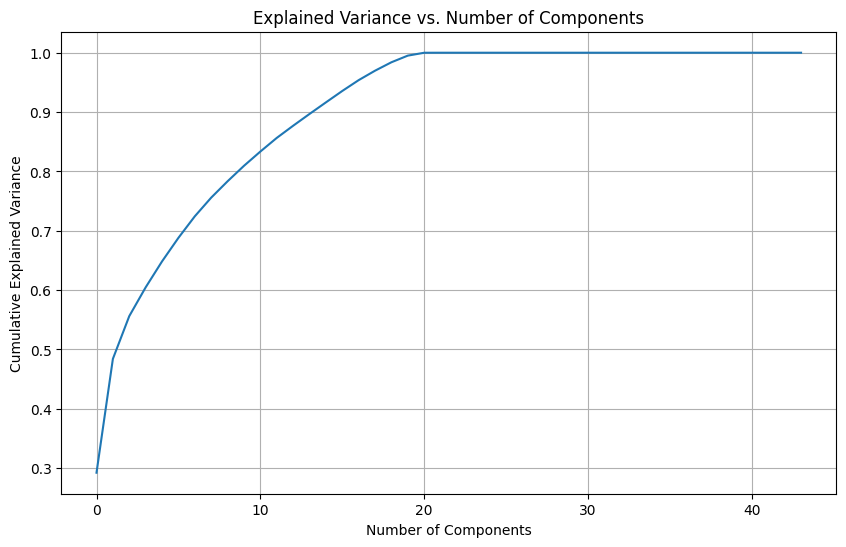

Number of components to explain 95% variance: 17
Shape of X_train after PCA: (5634, 17)
Shape of X_test after PCA: (1409, 17)


In [40]:
pca = PCA()
pca.fit(X_train_preprocessed)

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True)
plt.show()

explained_variance_95 = np.where(np.cumsum(pca.explained_variance_ratio_) >= 0.95)[0][0] + 1
print(f"Number of components to explain 95% variance: {explained_variance_95}")

pca_final = PCA(n_components=explained_variance_95)
X_train_pca = pca_final.fit_transform(X_train_preprocessed)
X_test_pca = pca_final.transform(X_test_preprocessed)

print(f"Shape of X_train after PCA: {X_train_pca.shape}")
print(f"Shape of X_test after PCA: {X_test_pca.shape}")

In [41]:
print("\nEigenvalues (Explained Variance):")
display(pd.DataFrame({'Eigenvalue': pca.explained_variance_}).T)

print("\nEigenvectors (Principal Components):\n(Each row is a principal component, ordered by explained variance)")
display(pd.DataFrame(pca.components_))


Eigenvalues (Explained Variance):


,0,1,2,3,4,5,6,7,8,9,...,34,35,36,37,38,39,40,41,42,43
Eigenvalue,3.350327,2.199929,0.825955,0.555672,0.501524,0.454982,0.416136,0.36053,0.316201,0.298545,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Eigenvectors (Principal Components):
(Each row is a principal component, ordered by explained variance)


,0,1,2,3,4,5,6,7,8,9,...,34,35,36,37,38,39,40,41,42,43
0,3.237996e-01,4.914976e-01,4.755852e-01,0.003887,-0.003887,-0.071070,0.071070,0.005275,-0.005275,-0.008918,...,0.169664,-0.054382,0.020474,0.033908,-0.091322,0.091322,0.031306,0.028286,0.038020,-0.097612
1,4.779465e-01,-1.915566e-01,2.825437e-01,0.000377,-0.000377,-0.133806,0.133806,-0.105506,0.105506,-0.016302,...,0.005495,-0.246768,0.065903,0.180865,0.097357,-0.097357,0.051225,0.061853,-0.139487,0.026409
2,1.406241e-01,-2.781447e-01,-3.115767e-02,-0.016557,0.016557,-0.078969,0.078969,-0.109096,0.109096,0.189592,...,-0.106798,-0.099986,0.039650,0.060335,0.119233,-0.119233,0.038341,0.054633,-0.120343,0.027369
3,9.718706e-02,-5.472287e-02,9.125060e-02,0.013717,-0.013717,0.494363,-0.494363,0.434132,-0.434132,0.065470,...,0.060950,-0.064249,0.038524,0.025726,0.042509,-0.042509,0.018293,0.016021,-0.060032,0.025718
4,-5.331151e-02,2.273108e-02,-2.165667e-02,0.700567,-0.700567,-0.019089,0.019089,-0.016652,0.016652,-0.005762,...,0.009524,0.002616,-0.006198,0.003582,-0.008326,0.008326,0.007237,-0.000793,-0.022810,0.016366
5,3.608492e-01,-1.671722e-01,1.170870e-01,0.060871,-0.060871,0.029054,-0.029054,0.139955,-0.139955,-0.041510,...,-0.316765,0.040658,-0.062448,0.021790,-0.124796,0.124796,0.049905,0.025587,0.018282,-0.093773
6,-7.574539e-02,2.338100e-01,8.697172e-02,-0.018249,0.018249,0.045228,-0.045228,0.006288,-0.006288,-0.231372,...,-0.144848,-0.015367,0.022130,-0.006763,0.482138,-0.482138,0.021154,-0.002048,-0.110967,0.091861
7,4.176638e-02,-5.664537e-02,-4.853904e-02,0.054082,-0.054082,-0.048854,0.048854,0.041765,-0.041765,0.141158,...,0.123952,0.031627,-0.055188,0.023561,0.441275,-0.441275,-0.010726,-0.033978,0.118770,-0.074066
8,2.080972e-01,-3.452630e-02,4.808880e-02,0.027455,-0.027455,-0.001903,0.001903,0.045570,-0.045570,-0.070403,...,-0.025727,-0.114951,0.049615,0.065337,-0.066547,0.066547,0.066309,0.059076,-0.057180,-0.068205
9,-2.376060e-01,9.245847e-02,-8.115938e-02,-0.016055,0.016055,0.063167,-0.063167,-0.087124,0.087124,-0.048460,...,-0.053599,0.072048,-0.145104,0.073056,-0.096275,0.096275,-0.016966,0.015924,-0.118317,0.119360


In [42]:
print("\nCovariance Matrix of the preprocessed training data:")
display(pd.DataFrame(pca.get_covariance()))


Covariance Matrix of the preprocessed training data:


,0,1,2,3,4,5,6,7,8,9,...,34,35,36,37,38,39,40,41,42,43
0,1.000178,0.253848,0.826584,-0.000341,0.000341,-0.189425,0.189425,-0.074268,0.074268,-0.001933,...,0.141965,-0.318818,0.083512,0.235307,-0.004016,0.004016,0.093545,0.098031,-0.094664,-0.096912
1,0.253848,1.000178,0.652892,0.009142,-0.009142,-0.052889,0.052889,0.051648,-0.051648,-0.074283,...,0.306397,0.028910,0.001356,-0.030267,-0.175238,0.175238,0.021629,0.010568,0.126559,-0.158757
2,0.826584,0.652892,1.000178,0.003130,-0.003130,-0.161124,0.161124,-0.030327,0.030327,-0.034031,...,0.254610,-0.221190,0.069792,0.151398,-0.080232,0.080232,0.074599,0.074856,-0.026404,-0.123051
3,-0.000341,0.009142,0.003130,0.249890,-0.249890,-0.001761,0.001761,0.002235,-0.002235,-0.001623,...,0.002272,0.000498,-0.002120,0.001622,-0.003872,0.003872,0.002376,0.000132,-0.001785,-0.000723
4,0.000341,-0.009142,-0.003130,-0.249890,0.249890,0.001761,-0.001761,-0.002235,0.002235,0.001623,...,-0.002272,-0.000498,0.002120,-0.001622,0.003872,-0.003872,-0.002376,-0.000132,0.001785,0.000723
5,-0.189425,-0.052889,-0.161124,-0.001761,0.001761,0.249806,-0.249806,0.103051,-0.103051,0.004345,...,-0.028125,0.070281,-0.017525,-0.052756,-0.004111,0.004111,-0.019904,-0.020495,0.020124,0.020274
6,0.189425,0.052889,0.161124,0.001761,-0.001761,-0.249806,0.249806,-0.103051,0.103051,-0.004345,...,0.028125,-0.070281,0.017525,0.052756,0.004111,-0.004111,0.019904,0.020495,-0.020124,-0.020274
7,-0.074268,0.051648,-0.030327,0.002235,-0.002235,0.103051,-0.103051,0.209524,-0.209524,0.000336,...,0.007508,0.052363,-0.012240,-0.040123,-0.023833,0.023833,-0.006956,-0.014818,0.033142,-0.011368
8,0.074268,-0.051648,0.030327,-0.002235,0.002235,-0.103051,0.103051,-0.209524,0.209524,-0.000336,...,-0.007508,-0.052363,0.012240,0.040123,0.023833,-0.023833,0.006956,0.014818,-0.033142,0.011368
9,-0.001933,-0.074283,-0.034031,-0.001623,0.001623,0.004345,-0.004345,0.000336,-0.000336,0.088393,...,0.004215,-0.000366,0.001110,-0.000744,0.002622,-0.002622,-0.000762,0.001914,-0.000334,-0.000818


In [43]:
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [44]:
# from tensorflow.keras import regularizers

model = Sequential([
    Dense(128, activation = 'relu', input_shape = (X_train_pca.shape[1],)),# kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),
    Dense(64, activation = 'relu'),
    layers.Dropout(0.3),
    Dense(1, activation = 'sigmoid')
])

model.compile(optimizer = 'adam', loss = tf.keras.losses.BinaryCrossentropy(), metrics = ['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [45]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,625 (41.50 KB)

 Trainable params: 10,625 (41.50 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train_pca, y_train, epochs = 50, batch_size = 32, validation_split = 0.2, callbacks=[early_stopping])

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.7637 - loss: 0.4788 - val_accuracy: 0.7959 - val_loss: 0.4255
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7910 - loss: 0.4464 - val_accuracy: 0.8021 - val_loss: 0.4201
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7912 - loss: 0.4388 - val_accuracy: 0.8083 - val_loss: 0.4188
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7954 - loss: 0.4331 - val_accuracy: 0.8048 - val_loss: 0.4186
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7957 - loss: 0.4329 - val_accuracy: 0.8057 - val_loss: 0.4155
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8041 - loss: 0.4278 - val_accuracy: 0.8083 - val_loss: 0.4122
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7990 - loss: 0.4255 - val_accuracy: 0.8083 - val_loss: 0.4123
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8054 - loss: 0.4284 - val_accuracy: 0

In [47]:
model.evaluate(X_test_pca, y_test)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8119 - loss: 0.4079


[0.40793949365615845, 0.8119233250617981]

In [48]:
y_pred = model.predict(X_test_pca)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [49]:
ypred = (y_pred > 0.5).astype(int).flatten()

In [50]:
accuracy_ANN = accuracy_score(y_test, ypred)

In [51]:
print(f"Accuracy of ANN: {accuracy_ANN}")

Accuracy of ANN: 0.8119233498935415


### ANN Model Evaluation and Learning Curves

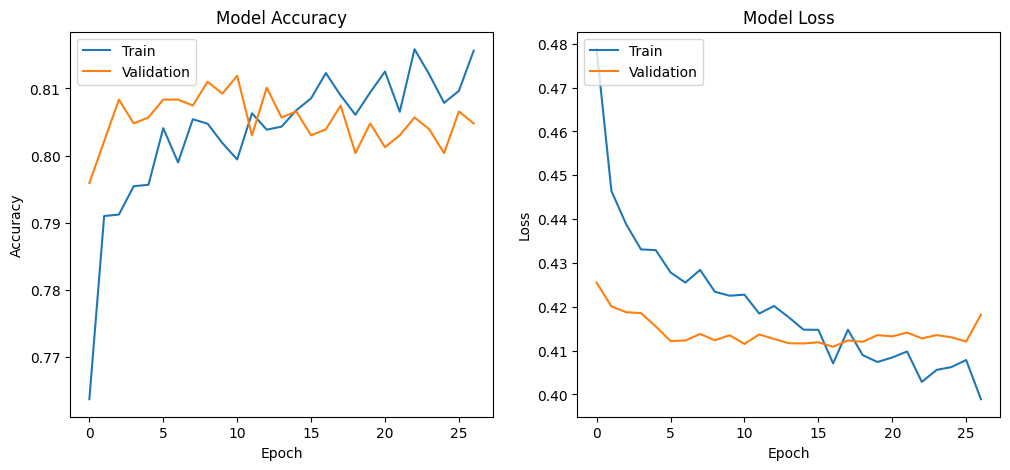

In [52]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [53]:
print('Classification Report for ANN:')
print(classification_report(y_test, ypred))

print('Confusion Matrix for ANN:')
print(confusion_matrix(y_test, ypred))

Classification Report for ANN:
              precision    recall  f1-score   support

           0       0.86      0.89      0.87      1036
           1       0.66      0.58      0.62       373

    accuracy                           0.81      1409
   macro avg       0.76      0.74      0.75      1409
weighted avg       0.81      0.81      0.81      1409

Confusion Matrix for ANN:
[[926 110]
 [155 218]]


In [54]:
from tensorflow.keras.layers import Conv2D, Flatten, MaxPooling2D

In [55]:
data = "/content/fashion-product-images-small/images"

In [60]:
import pandas as pd
import os

styles_file_path = os.path.join(path, "styles.csv")

df = pd.read_csv(styles_file_path, on_bad_lines='skip')

display(df.head())

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [61]:
import numpy as np

# Ensure the 'id' column in the DataFrame is in a format that matches image filenames
# Image filenames are typically 'id.jpg'
df['id'] = df['id'].astype(str)

# Get a list of all image file paths
image_dir = os.path.join(path, "images")
image_files = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]
image_ids_in_folder = [os.path.splitext(f)[0] for f in image_files]

# Filter the DataFrame to include only images that actually exist in the folder
# This also creates a copy to avoid SettingWithCopyWarning
filtered_df = df[df['id'].isin(image_ids_in_folder)].copy()

# Add the full image path to the DataFrame
filtered_df['image_path'] = filtered_df['id'].apply(lambda x: os.path.join(image_dir, x + '.jpg'))

# Verify that all image paths actually exist
filtered_df = filtered_df[filtered_df['image_path'].apply(os.path.exists)]

print(f"Original DataFrame size: {len(df)}")
print(f"Images found in folder: {len(image_ids_in_folder)}")
print(f"Filtered DataFrame size (images with existing files): {len(filtered_df)}")

# Display the updated DataFrame with image paths and labels
display(filtered_df.head())

Original DataFrame size: 44424
Images found in folder: 44441
Filtered DataFrame size (images with existing files): 44419


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image_path
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,/content/fashion-product-images-small/images/1...
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,/content/fashion-product-images-small/images/3...
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,/content/fashion-product-images-small/images/5...
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,/content/fashion-product-images-small/images/2...
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,/content/fashion-product-images-small/images/5...


In [63]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Choose the target label. For example, 'articleType' or 'masterCategory'
target_label = 'articleType'

# Drop rows where the target label might be missing
processed_df = filtered_df.dropna(subset=[target_label]).copy()

# Calculate the counts of each class
class_counts = processed_df[target_label].value_counts()
# Identify classes with only one sample
single_sample_classes = class_counts[class_counts < 2].index

# Filter out rows belonging to single-sample classes
processed_df = processed_df[~processed_df[target_label].isin(single_sample_classes)].copy()

# Encode the target labels
label_encoder = LabelEncoder()
processed_df['encoded_label'] = label_encoder.fit_transform(processed_df[target_label])

# Display the mapping of original labels to encoded integers
print("Label mapping (after filtering single-sample classes):")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label}: {i}")

# Separate image paths and encoded labels
image_paths = processed_df['image_path'].values
labels = processed_df['encoded_label'].values

# Split the data into training and testing sets
# We stratify to ensure that each split has approximately the same percentage of samples of each target class
train_images, test_images, train_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"\nTotal images (after filtering): {len(image_paths)}")
print(f"Training images: {len(train_images)}")
print(f"Test images: {len(test_images)}")
print(f"Number of unique labels (after filtering): {len(label_encoder.classes_)}")

Label mapping (after filtering single-sample classes):
Accessory Gift Set: 0
Baby Dolls: 1
Backpacks: 2
Bangle: 3
Basketballs: 4
Bath Robe: 5
Beauty Accessory: 6
Belts: 7
Blazers: 8
Body Lotion: 9
Booties: 10
Boxers: 11
Bra: 12
Bracelet: 13
Briefs: 14
Camisoles: 15
Capris: 16
Caps: 17
Casual Shoes: 18
Churidar: 19
Clothing Set: 20
Clutches: 21
Compact: 22
Concealer: 23
Cufflinks: 24
Deodorant: 25
Dresses: 26
Duffel Bag: 27
Dupatta: 28
Earrings: 29
Eye Cream: 30
Eyeshadow: 31
Face Moisturisers: 32
Face Scrub and Exfoliator: 33
Face Serum and Gel: 34
Face Wash and Cleanser: 35
Flats: 36
Flip Flops: 37
Footballs: 38
Formal Shoes: 39
Foundation and Primer: 40
Fragrance Gift Set: 41
Free Gifts: 42
Gloves: 43
Hair Colour: 44
Handbags: 45
Hat: 46
Headband: 47
Heels: 48
Highlighter and Blush: 49
Innerwear Vests: 50
Jackets: 51
Jeans: 52
Jeggings: 53
Jewellery Set: 54
Jumpsuit: 55
Kajal and Eyeliner: 56
Key chain: 57
Kurta Sets: 58
Kurtas: 59
Kurtis: 60
Laptop Bag: 61
Leggings: 62
Lehenga Choli

In [64]:
train_images.shape

(35530,)

### Image Preprocessing for CNN

In [65]:
import tensorflow as tf
import numpy as np

# Define image dimensions
IMG_HEIGHT = 128
IMG_WIDTH = 128
CHANNELS = 3

def load_and_preprocess_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=CHANNELS)
    img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
    img = tf.cast(img, tf.float32) / 255.0  # Normalize to [0,1]
    return img, label

# Create TensorFlow datasets
train_ds = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
train_ds = train_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(buffer_size=1000).batch(32).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_images, test_labels))
test_ds = test_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(32).prefetch(tf.data.AUTOTUNE)

print(f"Training dataset created with {len(train_images)} images.")
print(f"Test dataset created with {len(test_images)} images.")

# Example of one batch from the training dataset
for image_batch, label_batch in train_ds.take(1):
    print(f"Image batch shape: {image_batch.shape}")
    print(f"Label batch shape: {label_batch.shape}")

Training dataset created with 35530 images.
Test dataset created with 8883 images.
Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)


### Build and Train the CNN Model

In [76]:
from tensorflow.keras import layers, models

num_classes = len(np.unique(train_labels))

model_cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    layers.Dropout(0.6), # Added dropout for regularization
    Dense(num_classes, activation='softmax') # Softmax for multi-class classification
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [77]:
model_cnn.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

model_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 136)            │        17,544 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,322,184 (12.67 MB)

 Trainable params: 3,322,184 (12.67 MB)

 Non-trainable params: 0 (0.00 B)

In [78]:
history_cnn = model_cnn.fit(
    train_ds,
    epochs=10, # You can increase this for better convergence
    validation_data=test_ds
)

Epoch 1/10
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 35s 27ms/step - accuracy: 0.4667 - loss: 2.1978 - val_accuracy: 0.6856 - val_loss: 1.2400
Epoch 2/10
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 28s 25ms/step - accuracy: 0.6143 - loss: 1.4426 - val_accuracy: 0.7388 - val_loss: 0.9465
Epoch 3/10
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 27s 24ms/step - accuracy: 0.6550 - loss: 1.2248 - val_accuracy: 0.7660 - val_loss: 0.8225
Epoch 4/10
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 27s 24ms/step - accuracy: 0.6895 - loss: 1.0930 - val_accuracy: 0.7751 - val_loss: 0.7546
Epoch 5/10
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 25s 22ms/step - accuracy: 0.7149 - loss: 0.9814 - val_accuracy: 0.7920 - val_loss: 0.6984
Epoch 6/10
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 25s 22ms/step - accuracy: 0.7289 - loss: 0.9061 - val_accuracy: 0.8005 - val_loss: 0.6823
Epoch 7/10
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 25s 22ms/step - accuracy: 0.7448 - loss: 0.8445 - val_accuracy: 0.8066 - val_loss: 0.6593
Epoch 8/10
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 25s 22ms/step - accuracy: 0.7625 -

### Evaluate the CNN Model and Visualize Learning Curves

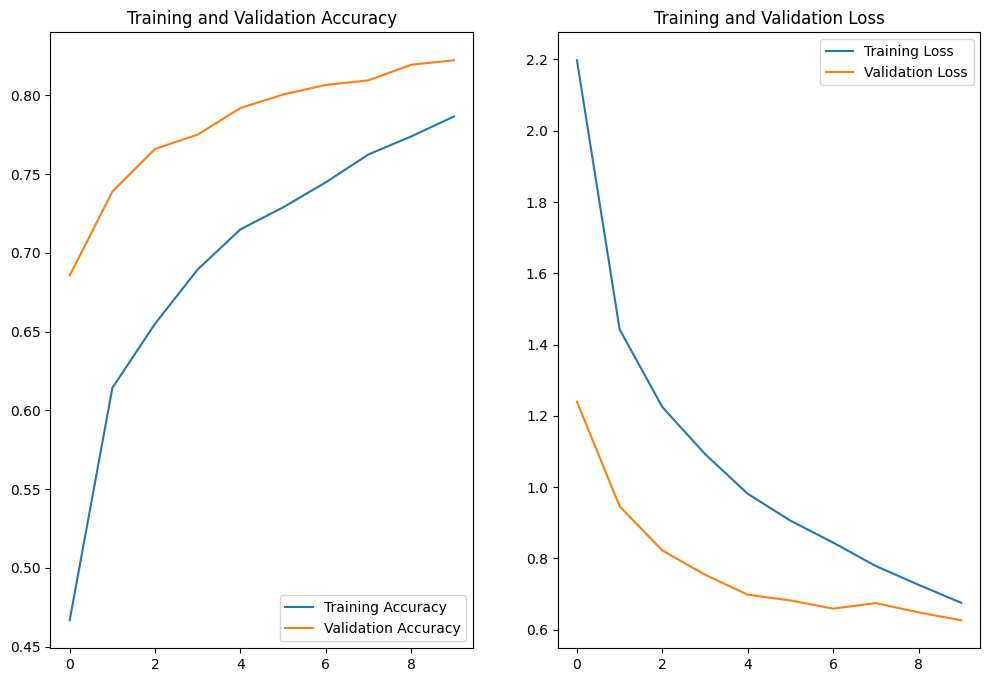

In [79]:
import matplotlib.pyplot as plt

acc = history_cnn.history['accuracy']
val_acc = history_cnn.history['val_accuracy']

loss = history_cnn.history['loss']
val_loss = history_cnn.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [80]:
loss, accuracy = model_cnn.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

278/278 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8222 - loss: 0.6267
Test Loss: 0.6267
Test Accuracy: 0.8222


In [81]:
y_pred = model_cnn.predict(test_ds)

278/278 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step


In [82]:
import numpy as np
ypred = np.argmax(y_pred, axis = 1)
accuracy_cnn = accuracy_score(test_labels, ypred)
print(f"Accuracy of CNN: {accuracy_cnn}")

Accuracy of CNN: 0.8222447371383541


In [83]:
from tensorflow.keras import applications

In [84]:
base_model = applications.ResNet50V2(weights = 'imagenet', include_top = False, input_shape = (160, 160, 3))

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [85]:
base_model.trainable = False

In [107]:
model_T = Sequential([
    layers.Lambda(lambda image: tf.image.resize(image, (160, 160))),
    # layers.Lambda(lambda x: tf.image.grayscale_to_rgb(x)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation = 'relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation = 'softmax')
])

In [108]:
model_T.compile(optimizer = 'adam', loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), metrics = ['accuracy'])

In [109]:
model_T.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_2 (Lambda)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 5, 5, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,564,800 (89.89 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,564,800 (89.89 MB)

In [110]:
history_T = model_T.fit(
    train_ds,
    epochs=15,
    validation_data=test_ds)

Epoch 1/15
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 84s 65ms/step - accuracy: 0.6338 - loss: 1.4502 - val_accuracy: 0.7556 - val_loss: 0.8390
Epoch 2/15
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 67s 55ms/step - accuracy: 0.7242 - loss: 0.9499 - val_accuracy: 0.7755 - val_loss: 0.7321
Epoch 3/15
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 90s 63ms/step - accuracy: 0.7456 - loss: 0.8414 - val_accuracy: 0.7905 - val_loss: 0.6832
Epoch 4/15
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 62s 55ms/step - accuracy: 0.7606 - loss: 0.7705 - val_accuracy: 0.7966 - val_loss: 0.6571
Epoch 5/15
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 60s 54ms/step - accuracy: 0.7730 - loss: 0.7235 - val_accuracy: 0.8012 - val_loss: 0.6466
Epoch 6/15
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 60s 54ms/step - accuracy: 0.7813 - loss: 0.6869 - val_accuracy: 0.8075 - val_loss: 0.6317
Epoch 7/15
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 60s 53ms/step - accuracy: 0.7891 - loss: 0.6534 - val_accuracy: 0.8087 - val_loss: 0.6396
Epoch 8/15
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 60s 54ms/step - accuracy: 0.7924 -

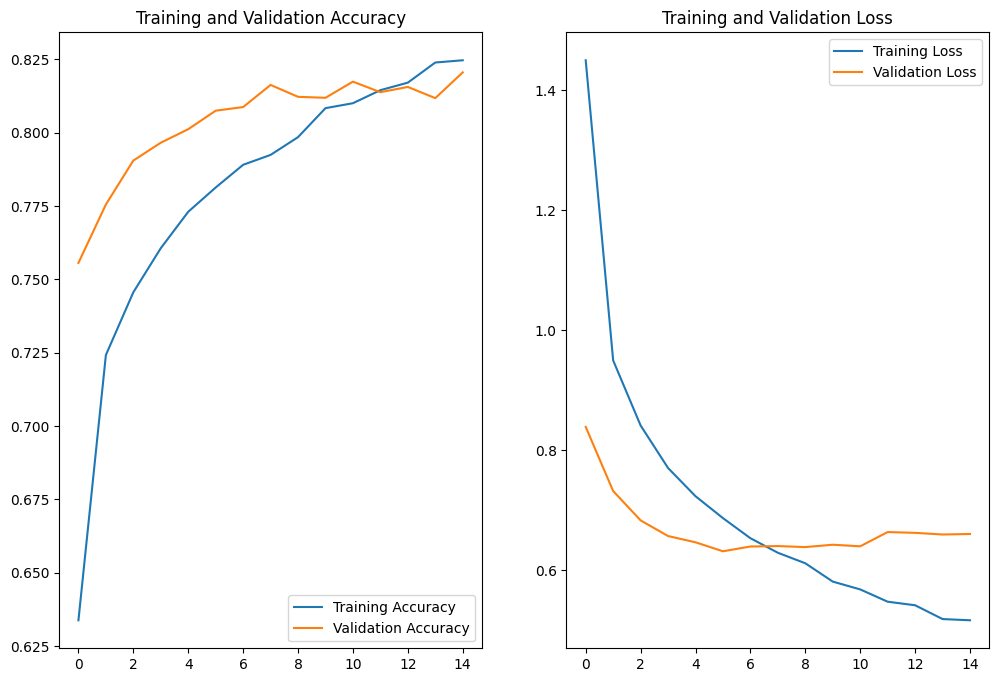

In [111]:
import matplotlib.pyplot as plt

acc = history_T.history['accuracy']
val_acc = history_T.history['val_accuracy']

loss = history_T.history['loss']
val_loss = history_T.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [112]:
loss, accuracy = model_T.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

278/278 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.8206 - loss: 0.6605
Test Loss: 0.6605
Test Accuracy: 0.8206


In [113]:
y_pred = model_T.predict(test_ds)

278/278 ━━━━━━━━━━━━━━━━━━━━ 19s 56ms/step


In [114]:
import numpy as np
ypred = np.argmax(y_pred, axis = 1)
accuracy_T = accuracy_score(test_labels, ypred)
print(f"Accuracy of CNN: {accuracy_T}")

Accuracy of CNN: 0.8205561184284589


### Object Detection with YOLOv8

First, we need to install the `ultralytics` library, which provides the YOLOv8 models.

In [ ]:
!pip install ultralytics -qq
import ultralytics
ultralytics.checks()

Now, let's load a pre-trained YOLOv8 model. We'll use `yolov8n.pt` which is a small, fast model for demonstration purposes. We'll also take one of the test images to demonstrate its usage.

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Load a pretrained YOLOv8n model
model = YOLO('yolov8n.pt')

# Take a sample image from the test set for demonstration
sample_image_path = test_images[0]

print(f"Loaded YOLOv8 model: {model.yaml['model_type']}")
print(f"Using sample image for inference: {sample_image_path}")

Next, we will run inference on the sample image and then parse the results to extract and display the bounding boxes.

In [ ]:
from PIL import Image

# Perform inference on the sample image
results = model(sample_image_path)

# Process results
for r in results:
    im_array = r.plot()  # plot returns an opencv image (BGR array)
    im = Image.fromarray(im_array[..., ::-1])  # RGB PIL image

    plt.figure(figsize=(10, 10))
    plt.imshow(im)
    plt.axis('off')
    plt.title(f"Object Detection on: {os.path.basename(sample_image_path)}")
    plt.show()

    print("\nDetected Objects and Bounding Box Coordinates (xyxy format):")
    for box in r.boxes:
        # Convert tensor to numpy array for printing
        xyxy = box.xyxy[0].cpu().numpy()  # Bounding box coordinates (x1, y1, x2, y2)
        conf = box.conf[0].cpu().numpy()  # Confidence score
        cls = box.cls[0].cpu().numpy()    # Class ID

        print(f"  Class ID: {int(cls)}, Confidence: {conf:.2f}, BBox: {xyxy.round(2)}")

The above output shows the detected objects with their bounding boxes drawn on the image, along with a textual representation of their class ID, confidence score, and `xyxy` (top-left x, top-left y, bottom-right x, bottom-right y) bounding box coordinates.